# Metamorphosis solver -- test notebook

End-to-end walkthrough of every piece of the `src/` object model: image
loading, the individual building blocks of the exact solver (kernel,
velocity field, trajectory, warp, energy), both solvers (exact and
simplified) -- each stopping on convergence rather than a fixed iteration
count, with their loss curves plotted -- and the visualizer.

Pyramid scales below stop at half resolution so the notebook runs in
about a minute; the finest (native-resolution) level is far more
expensive per iteration -- a single run there took ~3 minutes in
testing. Extend `pyramid_scales` to `(..., 1.0)` for a production run.
The final section exports everything for the experiment run in this
notebook into `notebook_outputs/`.

In [1]:
import os
import sys
sys.path.insert(0, "src")

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

%matplotlib inline

A0_PATH = "/Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/preprocessed/aligned_0__20141014_mapped.png"
A1_PATH = "/Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/preprocessed/aligned_4__20171221_mapped.png"

## 1. Load the input images

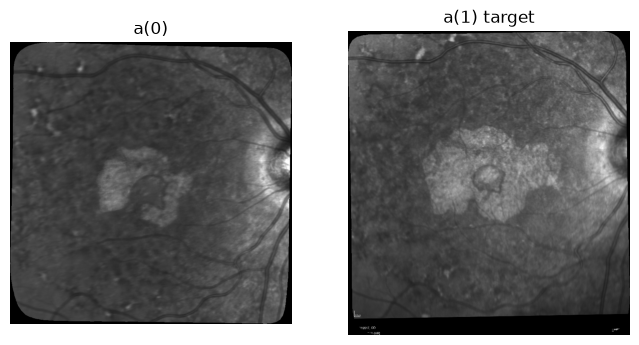

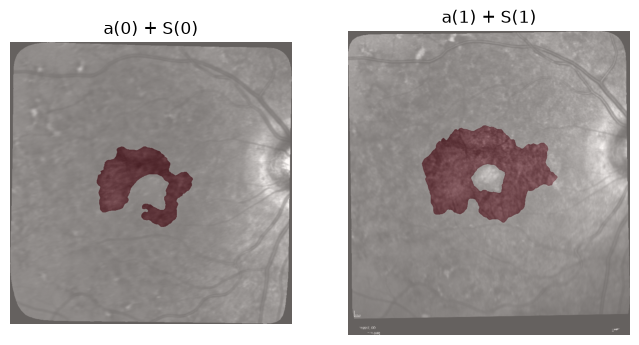

In [2]:
from core.Image import Image

img0 = Image(A0_PATH)
img1 = Image(A1_PATH)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img0.array, cmap="gray"); axes[0].set_title("a(0)"); axes[0].axis("off")
axes[1].imshow(img1.array, cmap="gray"); axes[1].set_title("a(1) target"); axes[1].axis("off")
S0_PATH = "/Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/segmentations/frame_00.png"
S1_PATH = "/Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/segmentations/frame_04.png"

mask0 = Image(S0_PATH)
mask1 = Image(S1_PATH)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img0.array, cmap="gray"); axes[0].imshow(mask0.array, cmap="Reds", alpha=0.4)
axes[0].set_title("a(0) + S(0)"); axes[0].axis("off")
axes[1].imshow(img1.array, cmap="gray"); axes[1].imshow(mask1.array, cmap="Reds", alpha=0.4)
axes[1].set_title("a(1) + S(1)"); axes[1].axis("off")
plt.show()

## 2. Image preprocessing operators (`ImageOperators`)

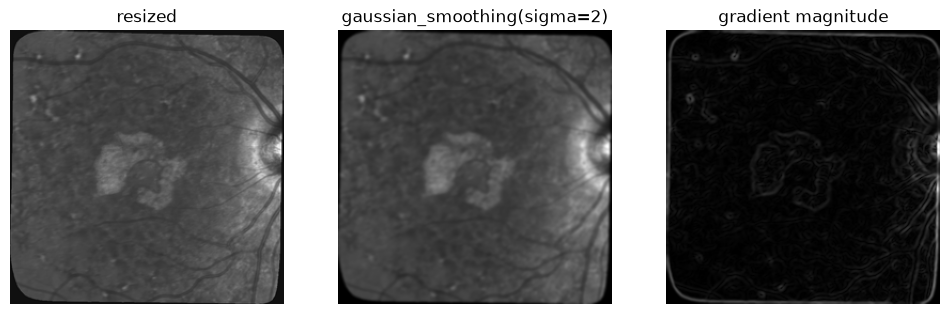

In [3]:
from core.Image import ImageOperators

resized = ImageOperators.resize(img0.array, (256, 256))
smoothed = ImageOperators.gaussian_smoothing(resized, sigma=1.0)
gx, gy = ImageOperators.gradient(smoothed)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(resized, cmap="gray"); axes[0].set_title("resized")
axes[1].imshow(smoothed, cmap="gray"); axes[1].set_title("gaussian_smoothing(sigma=2)")
axes[2].imshow(np.sqrt(gx**2 + gy**2), cmap="gray"); axes[2].set_title("gradient magnitude")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. The building blocks of the exact solver (book section 13.4.3)

- `GaussianKernel` -- K and K^(1/2)
- `VelocityField` -- w(t) and v(t) = K^(1/2) w(t)
- `ImageTrajectory` -- free intermediate states a(1..T-1)
- `SemiLagrangianWarp` -- bilinear transport a(t+1, x + dt*v)
- `MetamorphosisEnergy` -- formula (13.13)

At zero-initialized w, v=0 and the trajectory is just the linear blend
between a(0) and a(1), so `E_data` below is the mismatch of a naive
linear interpolation -- the optimizer's job (next section) is to drive
it down.

In [4]:
from forward.Metamorphosis import Metamorphosis

seg_demo_kwargs = dict(
    T=4, kernel_sigma_frac=0.03,
    pyramid_scales=(0.25,),
    level_iters=(20,),
    level_lrs=(0.01,),
    convergence_tol=1e-4, convergence_patience=5, convergence_min_iters=5,
    device="cpu"
)
metamorphosis_image_only = Metamorphosis.fit(
    A0_PATH, A1_PATH, lambda_data=200.0, verbose=False, **seg_demo_kwargs)
metamorphosis_seg = Metamorphosis.fit(
    A0_PATH, A1_PATH, path_s0=S0_PATH, path_s1=S1_PATH,
    lambda_data=10.0, lambda_seg=500.0, verbose=False, **seg_demo_kwargs)

In [5]:
from forward.Visualizer import MetamorphosisVisualizer

print("=== image-only ===")
print(MetamorphosisVisualizer(metamorphosis_image_only).summary())
print()
print("=== image + segmentation ===")
print(MetamorphosisVisualizer(metamorphosis_seg).summary())

=== image-only ===
Metamorphosis summary
a(0): /Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/preprocessed/aligned_0__20141014_mapped.png
a(1): /Users/clarachoukroun/Documents/Metamorphosis/BDD_AMD_062026/065_LE_A_OD/preprocessed/aligned_4__20171221_mapped.png
resolution solved at: 194x194, T=4 steps
  NB: input images are 776x777 natively -- pyramid_scales=[0.25] stopped short of 1.0, so this run (and every figure/frame below) is at 194x194, not native resolution.
lambda_data=200.0  kernel_sigma_frac=0.03

Final energy (finest level):
  loss         = 487,830.72
  E_kinetic    = 3,183.76
  E_data       = 151.4522  (rms 0.03172, ~8.09/255 gray levels)

Geometric deformation vs. residual:
  deformation (v):  50.7%   sum|v|=14,811.53
  residual    (z):  49.3%   sum|z|=14,397.51
  max net pixel displacement: 0.2738px  (mean 0.09608px)
  max |z| (single step):      0.7354

Final matching, a(T) vs target a(1):
  mean|diff|=0.00000  max|diff|=0.00000
  (exactly 0 be

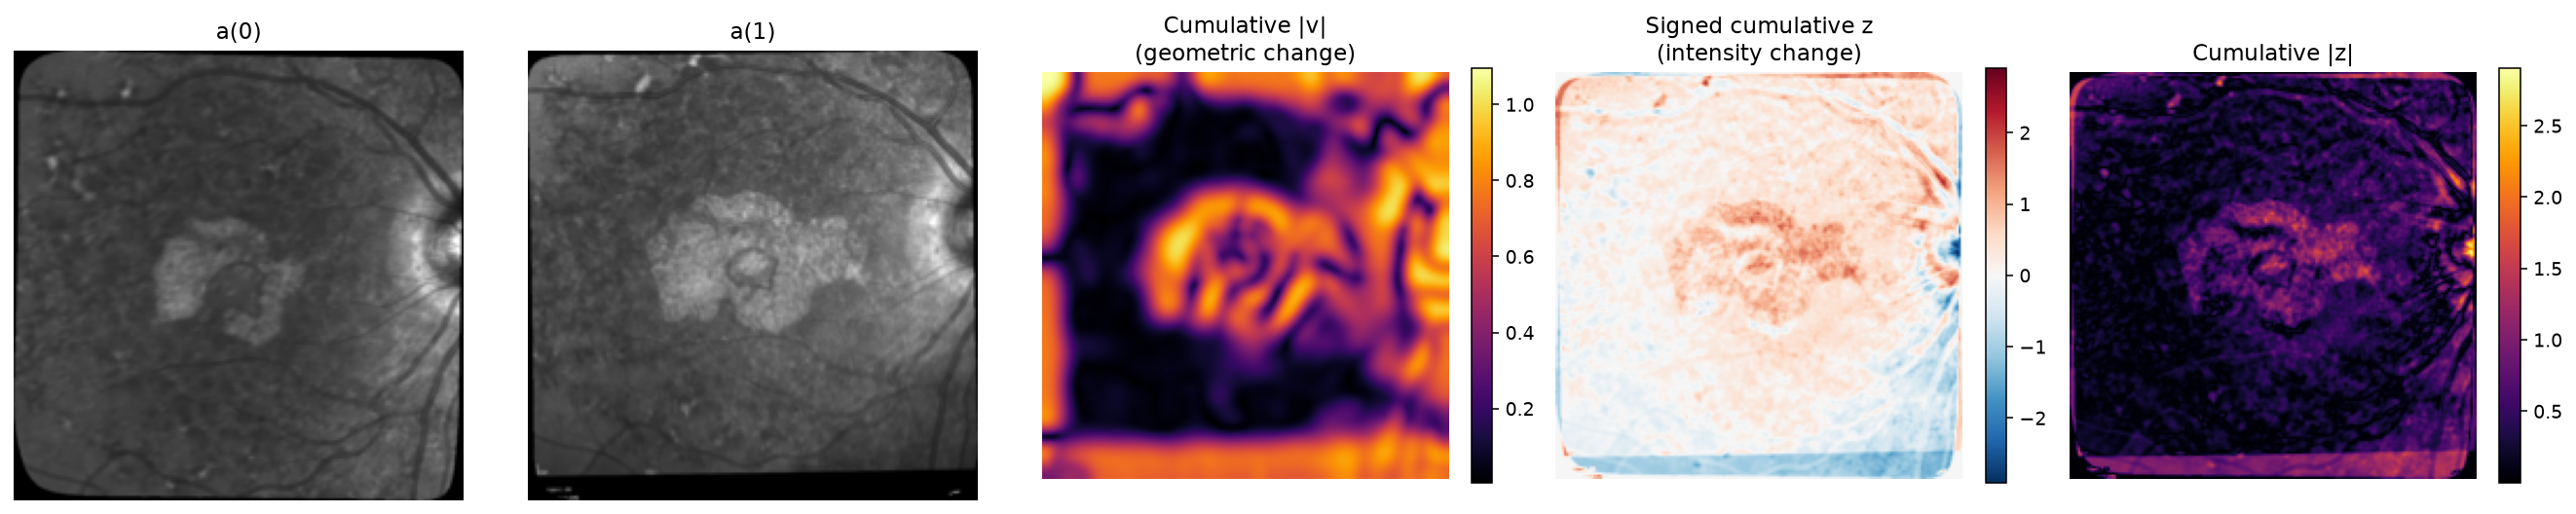

Saved image-only run to notebook_outputs_seg/


In [6]:
os.makedirs("notebook_outputs_seg", exist_ok=True)
viz_seg = MetamorphosisVisualizer(metamorphosis_image_only)



viz_seg.plot_deformation_vs_residual("notebook_outputs_seg/fig_v_vs_z.png")
display(IPImage("notebook_outputs_seg/fig_v_vs_z.png"))

metamorphosis_image_only.save("notebook_outputs_seg/metamorphosis_image_only.pt")
viz_seg.export_all("notebook_outputs_seg")
print("Saved image-only run to notebook_outputs_seg/")

## 4. Running `MetamorphosisSolver` directly (low-level)

Same objects as above, now driven through the full multi-resolution
optimization loop. `level_iters` is just a *cap* per level: each level
stops as soon as the loss hasn't improved by `convergence_tol` (relative)
for `convergence_patience` iterations -- see `src/Convergence.py`. A
`convergence_min_iters` warmup keeps the zero-deformation start (which
has zero kinetic cost) from looking like a false early optimum.